In [ ]:
import torch
import cv2
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt
from instaflow.pipeline_drag import RectifiedFlowStateMachine
from instaflow.utils import overlay_points_and_mask, set_seed, MaskPainter

import torch.nn.functional as F
from torchvision.transforms import Compose
from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import Resize, NormalizeImage, PrepareForNet

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

pipe = RectifiedFlowStateMachine.from_pretrained(
    "XCLiu/2_rectified_flow_from_sd_1_5", 
    torch_dtype=torch.bfloat16, 
    device_map=DEVICE
)
pipe.safety_checker = None

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /Data/yiming.chen/huggingface/hub/models--XCLiu--2_rectified_flow_from_sd_1_5/snapshots/934962eb1054b67883fabb3e0860b851baf31142/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Data/yiming.chen/huggingface/hub/models--XCLiu--2_rectified_flow_from_sd_1_5/snapshots/934962eb1054b67883fabb3e0860b851baf31142/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/Data/yiming.chen/envs/py311/lib/python3.11/site-packages/diffusers/loaders/lora_pipeline.py:5501: FutureWarning: `LoraLoaderMixin` is deprecated and will be removed in version 1.0.0. LoraLoaderMixin is deprecated and this will be removed in a future version. Please use `StableDiffusionLoraLoaderMixin`, instead.
  deprecate("LoraLoaderMixin", "1.0.0", deprecation_message)


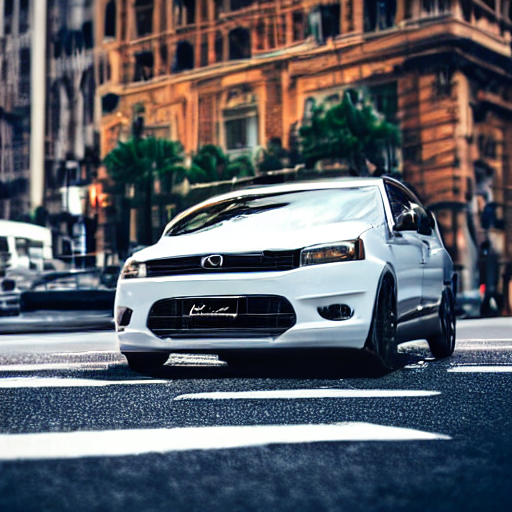

In [33]:
set_seed(512)
state_fg = pipe.prepare_state(
    prompt="A car in the city, high quality, detailed",
    height=512,
    width=512,
    num_inference_steps=50,
    guidance_scale=3,
    capture_all_intermediate_features=True,
)

def example_callback(i, t, dt, latent, features, v_pred):
    next_latent = latent + dt * v_pred
    return next_latent

state_fg = pipe.infer_from_state(state_fg, until=50, callback=example_callback)
img_fg = pipe.decode_latents(state_fg.latent)[0][0]
img_fg

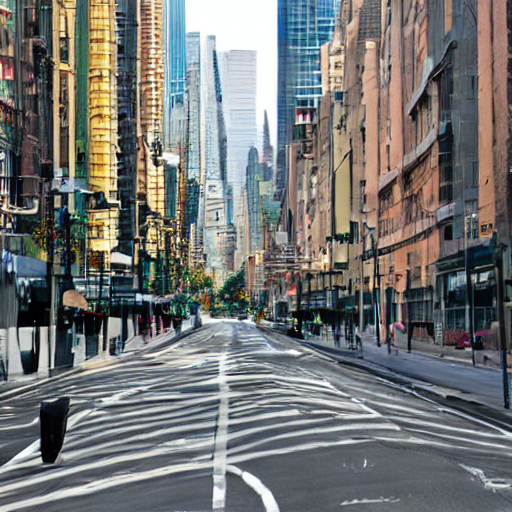

In [23]:
set_seed(25886)

state_bg = pipe.prepare_state(
    prompt="A city road, high quality, detailed",
    height=512,
    width=512,
    num_inference_steps=50,
    guidance_scale=1.5,
    capture_all_intermediate_features=False,
)

def example_callback(i, t, dt, latent, features, v_pred):
    next_latent = latent + dt * v_pred
    return next_latent

state_bg = pipe.infer_from_state(state_bg, until=50, callback=example_callback)
img_bg = pipe.decode_latents(state_bg.latent)[0][0]
img_bg

In [4]:
painter = MaskPainter(img_fg, brush_radius=20, fill_style="rgba(255, 255, 255, 0.8)")
painter.show()

Canvas(height=512, width=512)

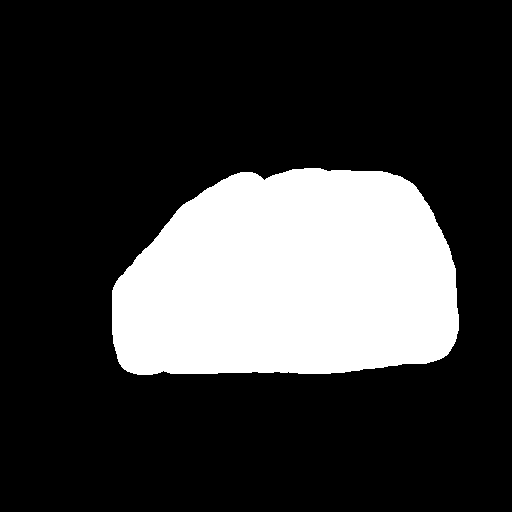

In [6]:
# show mask
mask = painter.get_mask()
mask_img = PIL.Image.fromarray((mask * 255).astype(np.uint8))
mask_img

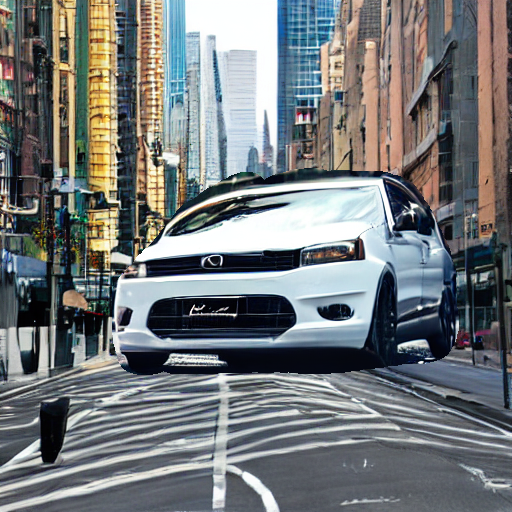

In [7]:
# Simple blending: mask * foreground + (1 - mask) * background
import PIL.Image
mask = painter.get_mask() # 0-1 numpy array dtype uint8

# Convert images to numpy arrays
fg_array = np.array(img_fg).astype(np.float32) / 255.0
bg_array = np.array(img_bg).astype(np.float32) / 255.0

# Blend: result = mask * fg + (1 - mask) * bg
mask_array = mask[:, :, np.newaxis]  # Add channel dimension
blended_array = mask_array * fg_array + (1.0 - mask_array) * bg_array

# Convert back to PIL Image
blended_img = PIL.Image.fromarray((blended_array * 255).astype(np.uint8))
blended_img

Mask tensor shape: torch.Size([1, 1, 512, 512]), dtype: torch.bfloat16
Method 1: Optimizing latent from step 20 to 25...
Cloning bg state and generating reference with features...
Starting blending optimization...
timestep 20...timestep 21...timestep 22...timestep 23...timestep 24...

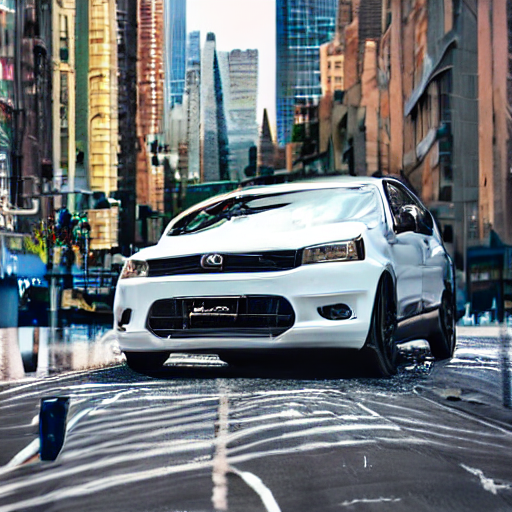

In [8]:
from instaflow.blend_transfer import BlendConfig, get_callback_with_fg_features

# Mask
mask_tensor = torch.from_numpy(mask).to(device=state_bg.device, dtype=state_bg.latent.dtype)
if mask_tensor.ndim == 2:
    mask_tensor = mask_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]

# Configs
config = BlendConfig(
    blend_start_step=20,
    blend_end_step=25,
    optim_steps_per_inference=10,
    lr=0.1,
    lamfg=0.01, # fg guidance scale
    lambg=0.001 # bg guidance scale
)

print(f"Mask tensor shape: {mask_tensor.shape}, dtype: {mask_tensor.dtype}")
print(f"Method 1: Optimizing latent from step {config.blend_start_step} to {config.blend_end_step}...")

# Clone bg state as reference and regenerate with features
print("Cloning bg state and generating reference with features...")
state_bg_ref = state_bg.clone()
state_bg_ref.capture_all_intermediate_features = True
state_bg_ref.intermediate_latents = []
state_bg_ref.reset()
state_bg_ref = pipe.infer_from_state(state_bg_ref, until=50, callback=example_callback)

print("Starting blending optimization...")
state_bg.reset()
state_bg = pipe.infer_from_state(
    state_bg,
    until=50,
    callback = get_callback_with_fg_features(pipe, state_fg, state_bg_ref, mask_tensor, config)
)
torch.cuda.empty_cache()
img_method1 = pipe.decode_latents(state_bg.latent)[0][0]
img_method1

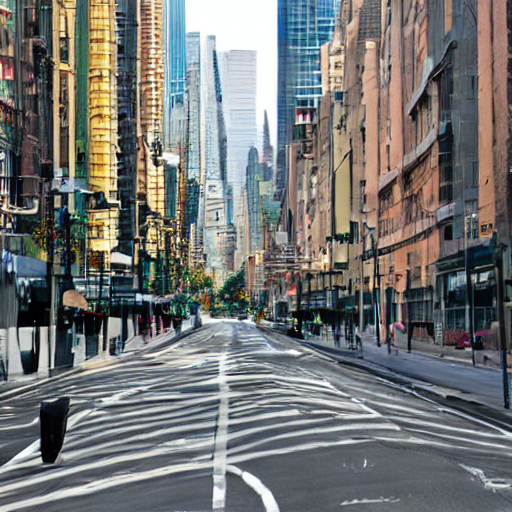

In [9]:
# Check if we succeeded in injecting the information by starting from the same seed
state_bg.reset()
state_bg = pipe.infer_from_state(state_bg, until=50, callback=None)
torch.cuda.empty_cache()
img_method1 = pipe.decode_latents(state_bg.latent)[0][0]
img_method1

## Depth-aware editing

Total parameters: 335.32M


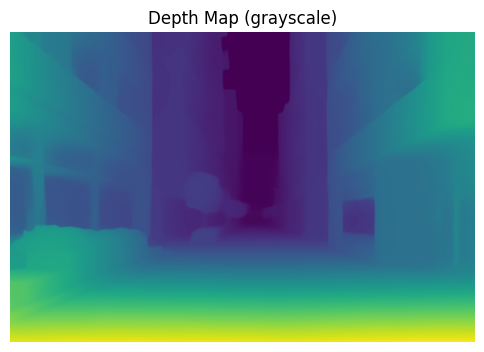

In [ ]:
ENCODER = 'vitl' # choices=['vits', 'vitb', 'vitl']
depth_anything = DepthAnything.from_pretrained(f'LiheYoung/depth_anything_{ENCODER}14').to(DEVICE).eval()

total_params = sum(param.numel() for param in depth_anything.parameters())
print('Total parameters: {:.2f}M'.format(total_params / 1e6))
    
transform = Compose([
    Resize(
        width=518,
        height=518,
        resize_target=False,
        keep_aspect_ratio=True,
        ensure_multiple_of=14,
        resize_method='lower_bound',
        image_interpolation_method=cv2.INTER_CUBIC,
    ),
    NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    PrepareForNet(),
])

# raw_image = cv2.imread(filename)
# image = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB) / 255.0
image = np.array(img_fg.convert("RGB")) / 255.0
        
h, w = image.shape[:2]
        
image = transform({'image': image})['image']
image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)
        
with torch.no_grad():
    depth = depth_anything(image)
        
    depth = F.interpolate(depth[None], (h, w), mode='bilinear', align_corners=False)[0, 0]
    depth = (depth - depth.min()) / (depth.max() - depth.min()) * 255.0
        
    depth = depth.cpu().numpy().astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(depth)
plt.axis('off')
plt.title('Depth Map (grayscale)')
plt.show()